In [19]:
from langgraph.graph import StateGraph, END
from langchain_core.runnables import RunnableLambda
from typing import TypedDict, Annotated, List, Literal,Tuple
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]
    check: Annotated[bool, 'true']
# 초기 상태 정의



# 사용자 메시지 노드
def add_user_message(state:State):
    state["messages"].append({"role": "user", "content": "LangGraph가 뭐야?"})
    return state

# 에이전트 응답 노드
def agent_response(state:State):
    state["messages"].append({"role": "ai", "content": "LangGraph는 LangChain 기반 워크플로우 프레임워크입니다."})
    return state

# 계속할지 판단 노드
def check_continue(state:State):
    # 예시로 상태에서 continue 값을 읽어 분기
    if state.get("check",False):
        return "check"
    else:
        return "end"

# 그래프 빌더 생성
builder = StateGraph(State)
builder.add_node("add_user", RunnableLambda(add_user_message))
builder.add_node("agent", RunnableLambda(agent_response))

# 노드 연결
builder.set_entry_point("add_user")
builder.add_edge("add_user", "agent")

builder.add_conditional_edges(
    source="add_user", 
    path=check_continue,
    path_map={
    "check": "add_user",
    "end": END
})

# 그래프 컴파일
graph = builder.compile()


state = {
    "messages": [],
}
# 1. 초기 실행
final_state1 = graph.invoke(state)
print("== 첫 실행 ==")
for msg in final_state1["messages"]:
    print(msg)
    # print(f"{msg['role']}: {msg['content']}")

# 2. 상태 수정 후 재실행
final_state1["messages"] = {"role": "user", "content": "이게맞아?"}  # 상태값 변경

final_state2 = graph.invoke(final_state1)  # 변경된 상태로 재실행
print("\n== 수정 후 재실행 ==")
for msg in final_state2["messages"]:
    print(msg)


== 첫 실행 ==
content='LangGraph가 뭐야?' additional_kwargs={} response_metadata={} id='8be073a5-540b-4b2e-ba6a-3823f377909e'
content='LangGraph가 뭐야?' additional_kwargs={} response_metadata={} id='908d601b-6485-4571-8f5a-d37ca5cfcbe4'
content='LangGraph는 LangChain 기반 워크플로우 프레임워크입니다.' additional_kwargs={} response_metadata={} id='f7fae71a-2f4e-446c-ad73-12d3ee7d7fac'
content='LangGraph는 LangChain 기반 워크플로우 프레임워크입니다.' additional_kwargs={} response_metadata={} id='1cf6b10e-64cd-427a-ba9b-94691acd4c06'

== 수정 후 재실행 ==
content='이게맞아?' additional_kwargs={} response_metadata={} id='698648bf-14d1-4f58-8d37-16bb83b78d38'
content='LangGraph가 뭐야?' additional_kwargs={} response_metadata={} id='61ce6b20-e843-45a3-8758-bebc89c33fe8'
content='LangGraph가 뭐야?' additional_kwargs={} response_metadata={} id='be414f90-c2b2-4f52-a090-65eb5acc2cf3'
content='LangGraph는 LangChain 기반 워크플로우 프레임워크입니다.' additional_kwargs={} response_metadata={} id='c46bba14-b873-4d2c-a270-e7d7ca79f358'
content='LangGraph는 LangChain 기반 워크

In [30]:
from langgraph.graph import StateGraph, END
from langchain_core.runnables import RunnableLambda
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]
    check: Annotated[bool, 'true']

def add_user_message(state: State):
    return State({'messages':'LangGraph가 뭐야?'})

def agent_response(state: State):
    return State({'messages':'LangGraph는 LangChain 기반 워크플로우 프레임워크입니다.'})

def check_continue(state: State):
    if state.get("check", False):
        return "check"
    else:
        return "end"

builder = StateGraph(State)
builder.add_node("add_user", RunnableLambda(add_user_message))
builder.add_node("agent", RunnableLambda(agent_response))

builder.set_entry_point("add_user")
builder.add_edge("add_user", "agent")

builder.add_conditional_edges(
    source="agent",
    path=check_continue,
    path_map={
        "check": "add_user",
        "end": END
    }
)

graph = builder.compile()

state = {
    "messages": [],
    "check": False
}

# 1. 초기 실행 (전체 실행)
final_state1 = graph.invoke(state)
# print("== 첫 실행 ==")
# for msg in final_state1["messages"]:
#     print(msg)


In [31]:
final_state1

{'messages': [HumanMessage(content='LangGraph가 뭐야?', additional_kwargs={}, response_metadata={}, id='84afa102-3ed4-4182-9c77-80b36eab25f3'),
  HumanMessage(content='LangGraph는 LangChain 기반 워크플로우 프레임워크입니다.', additional_kwargs={}, response_metadata={}, id='cdd78930-6cea-4ba3-a0f1-63e9beee933b')],
 'check': False}

In [34]:

# 2. interrupt 사용하여 add_user 단계 직전에 실행 멈추기
# interrupt_before에 'add_user'를 넘기면 add_user 노드 직전에 멈춤
interrupted_states = list(graph.stream(final_state1, interrupt_before=["agent"]))


In [35]:
interrupted_states

[{'add_user': {'messages': 'LangGraph가 뭐야?'}}, {'__interrupt__': ()}]

In [36]:

# interrupt 상태(멈춘 상태) 얻기
interrupted_state = interrupted_states[-1]


In [37]:
interrupted_state

{'__interrupt__': ()}

In [38]:

# 3. interrupt 상태에서 messages 수정 (add_user 단계 수행 직전 상태)
interrupted_state["messages"] = [{"role": "user", "content": "이게 맞아?"}]


In [39]:
interrupted_state

{'__interrupt__': (), 'messages': [{'role': 'user', 'content': '이게 맞아?'}]}

In [40]:

# 4. 수정된 상태로 add_user부터 다시 실행
final_state2 = graph.invoke(interrupted_state)
print("\n== 수정 후 재실행 ==")
for msg in final_state2["messages"]:
    print(msg)



== 수정 후 재실행 ==
content='이게 맞아?' additional_kwargs={} response_metadata={} id='2727505f-ac38-48d5-8636-ce9454fde9c2'
content='LangGraph가 뭐야?' additional_kwargs={} response_metadata={} id='28ee344a-ee81-4dba-b852-cdd61899c74f'
content='LangGraph는 LangChain 기반 워크플로우 프레임워크입니다.' additional_kwargs={} response_metadata={} id='ec43d74e-32da-436b-b1d5-8d86fcb7d0ef'


In [25]:
from langchain_community.utilities import SQLDatabase

# SQLite 데이터베이스 파일에서 SQLDatabase 인스턴스 생성
db = SQLDatabase.from_uri("sqlite:///Chinook.db")

# DB dialect 출력(sqlite)
print(db.dialect)

# 데이터베이스에서 사용 가능한 테이블 이름 목록 출력
print(db.get_usable_table_names())

# SQL 쿼리 실행
# db.run("SELECT * FROM Genre LIMIT 5;")

# db.run("SELECT GenreId FROM Genre WHERE Name LIKE 'Rock';")

# db.run("SELECT Track.Name, Artist.Name AS ArtistName FROM Track JOIN Album ON Track.AlbumId = Album.AlbumId JOIN Artist " \
# "ON Album.ArtistId = Artist.ArtistId WHERE Track.GenreId IN (SELECT GenreId FROM Genre WHERE Name LIKE 'Rock') LIMIT 5;")

sqlite
['Album', 'Artist', 'Customer', 'Employee', 'Genre', 'Invoice', 'InvoiceLine', 'MediaType', 'Playlist', 'PlaylistTrack', 'Track']


''

In [2]:
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain_community.utilities import SQLDatabase
from langchain.chat_models import ChatOpenAI

# 1. 데이터베이스 연결 (예: SQLite 파일)
db = SQLDatabase.from_uri("sqlite:///Chinook.db")

# 2. LLM 인스턴스 생성 (OpenAI 예시)
llm = ChatOpenAI(model_name="gpt-4o-mini")

# 3. SQLDatabaseToolkit 생성 (db + llm)
toolkit = SQLDatabaseToolkit(db=db, llm=llm)

# 4. toolkit에서 도구들 가져오기
tools = toolkit.get_tools()


/tmp/ipykernel_424789/3608283097.py:9: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  llm = ChatOpenAI(model_name="gpt-4o-mini")


In [3]:
# 데이터베이스에서 사용 가능한 테이블을 나열하는 도구 선택
# list_tables_tool = next(tool for tool in tools if tool.name == "sql_db_list_tables")

# # 특정 테이블의 DDL을 가져오는 도구 선택
# get_schema_tool = next(tool for tool in tools if tool.name == "sql_db_schema")

# sql_db_query = next(tool for tool in tools if tool.name == "sql_db_query")
# 데이터베이스의 모든 테이블 목록 출력
# print(list_tables_tool.invoke(""))

# # Artist 테이블의 DDL 정보 출력
# print(get_schema_tool.invoke("Artist"))

# print(sql_db_query.invoke(" SELECT Track.Name, Artist.Name AS ArtistName FROM Track JOIN Album ON Track.AlbumId = Album.AlbumId JOIN Artist ON Album.ArtistId = Artist.ArtistId WHERE Track.Name IN ('서른 즈음에', '옛사랑', '야생화', '두 사람', '좋니');"))



In [4]:
def db_query_tool(query: str) -> str:
    """
    Run SQL queries against a database and return results
    Returns an error message if the query is incorrect
    If an error is returned, rewrite the query, check, and retry
    """
    # 쿼리 실행
    result = db.run_no_throw(query)
    # 오류: 결과가 없으면 오류 메시지 반환
    if "Error" in result:
        # 오류가 포함된 경우 처리
        print(result)
        print("에러가 발생했습니다.")
    elif not result:
        # 오류가 없을 경우 처리
        print("값이 없습니다")
    else:
        return result

In [15]:
# query ="SELECT Track.Name, Artist.Name AS ArtistName FROM Track JOIN Album ON Track.AlbumId = Album.AlbumId JOIN Artist ON Album.ArtistId = Artist.ArtistId WHERE Track.Name IN ('서른 즈음에', '옛사랑', '야생화', '두 사람', '좋니');"
# query = "SELECT * from Artist"
# query = " SELECT Name, Composer FROM Track WHERE GenreId NOT IN (1, 2, 3) LIMIT 5;"
# query = " select * from Genre;"
# query = "SELECT t.Name AS TrackName, a.Name AS ArtistName, t.Composer FROM Track t JOIN Album al ON t.AlbumId = al.AlbumId JOIN Artist a ON al.ArtistId = a.ArtistId JOIN Genre g ON t.GenreId = g.GenreId WHERE g.Name = 'Jazz' LIMIT 10;"
# query = "SELECT i.InvoiceId, il.TrackId, t.Name, t.GenreId, g.Name AS GenreName, il.Quantity, il.UnitPrice, (il.Quantity * il.UnitPrice) AS TotalPrice FROM InvoiceLine il JOIN Track t ON il.TrackId = t.TrackId JOIN Genre g ON t.GenreId = g.GenreId WHERE g.Name = 'Jazz';"
query = """
SELECT Track.Name AS TrackName, Artist.Name AS ArtistName FROM Track JOIN Album ON Track.AlbumId = Album.AlbumId WHERE Track.Name IN ('Peace Piece', 'Blue in Green', 'My Funny Valentine', 'Naima', 'The Girl from Ipanema', 'The Look of Love', 'Don\'t Know Why');"""
db_query_tool(query)

Error: (sqlite3.OperationalError) near "t": syntax error
[SQL: 
SELECT Track.Name AS TrackName, Artist.Name AS ArtistName FROM Track JOIN Album ON Track.AlbumId = Album.AlbumId WHERE Track.Name IN ('Peace Piece', 'Blue in Green', 'My Funny Valentine', 'Naima', 'The Girl from Ipanema', 'The Look of Love', 'Don't Know Why');]
(Background on this error at: https://sqlalche.me/e/20/e3q8)
에러가 발생했습니다.


### human in the loop

LangSmith 추적을 시작합니다.
[프로젝트명]
CH17-LangGraph-Modules


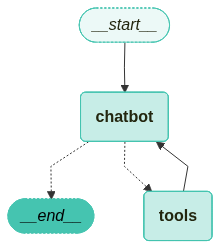

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv()

# LangSmith 추적을 설정합니다. https://smith.langchain.com
# !pip install -qU langchain-teddynote
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("CH17-LangGraph-Modules")


from typing import Annotated, List, Dict
from typing_extensions import TypedDict

from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_teddynote.graphs import visualize_graph
from langchain_teddynote.tools import GoogleNews


########## 1. 상태 정의 ##########
# 상태 정의
class State(TypedDict):
    # 메시지 목록 주석 추가
    messages: Annotated[list, add_messages]


########## 2. 도구 정의 및 바인딩 ##########
# 도구 초기화
# 키워드로 뉴스 검색하는 도구 생성
news_tool = GoogleNews()


@tool
def search_keyword(query: str) -> List[Dict[str, str]]:
    """Look up news by keyword"""
    news_tool = GoogleNews()
    return news_tool.search_by_keyword(query, k=5)


tools = [search_keyword]

# LLM 초기화
llm = ChatOpenAI(model="gpt-4o-mini")

# 도구와 LLM 결합
llm_with_tools = llm.bind_tools(tools)


########## 3. 노드 추가 ##########
# 챗봇 함수 정의
def chatbot(state: State):
    # 메시지 호출 및 반환
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# 상태 그래프 생성
graph_builder = StateGraph(State)

# 챗봇 노드 추가
graph_builder.add_node("chatbot", chatbot)


# 도구 노드 생성 및 추가
tool_node = ToolNode(tools=tools)

# 도구 노드 추가
graph_builder.add_node("tools", tool_node)

# 조건부 엣지
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

########## 4. 엣지 추가 ##########

# tools > chatbot
graph_builder.add_edge("tools", "chatbot")

# START > chatbot
graph_builder.add_edge(START, "chatbot")

# chatbot > END
graph_builder.add_edge("chatbot", END)

########## 5. MemorySaver 추가 ##########

# 메모리 저장소 초기화
memory = MemorySaver()

########## 6. interrupt_before 추가 ##########

# 그래프 빌더 컴파일
graph = graph_builder.compile(checkpointer=memory)

########## 7. 그래프 시각화 ##########
# 그래프 시각화
visualize_graph(graph)